Part 5: evaluation 

In this part, evaluate the two models based on FakeNewsCorpus test set, and LIAR dataset.

We train both models on FakeNewsCorpus dataset as done previously in Parts 3 and 4, then evaluate the results. After that, we load the LIAR dataset and use the test split to evaluate the models with it.

Similarly to Part 3 & 4, importing libraries, loading the FakeNewsCorpus cleaned dataset, and setting labels:

In [21]:
from pathlib import Path
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

#Adding import for MLP

from sklearn.neural_network import MLPClassifier


# Paths loading
if Path("data").exists():
    PROJECT_ROOT = Path(".")
elif Path("..").joinpath("data").exists():
    PROJECT_ROOT = Path("..")


PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_path = PROCESSED_DIR / "train.csv"
val_path = PROCESSED_DIR / "val.csv"
test_path = PROCESSED_DIR / "test.csv"

# Load splits files
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# Limiting size of the data for performance
train_df = train_df.sample(n=10000, random_state=42)
val_df = val_df.sample(n=2000, random_state=42)
test_df = test_df.sample(n=2000, random_state=42)

print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

required_cols = ["content", "type"]
for c in required_cols:
    if c not in train_df.columns:
        raise ValueError(f"Missing required column: {c}")

# Controlling the rows to load and performing training and validation
MAX_TRAIN_ROWS = 120_000
MAX_VAL_ROWS = 30_000
MAX_TEST_ROWS = 30_000

if MAX_TRAIN_ROWS is not None and len(train_df) > MAX_TRAIN_ROWS:
    train_df = train_df.sample(MAX_TRAIN_ROWS, random_state=42)
if MAX_VAL_ROWS is not None and len(val_df) > MAX_VAL_ROWS:
    val_df = val_df.sample(MAX_VAL_ROWS, random_state=42)
if MAX_TEST_ROWS is not None and len(test_df) > MAX_TEST_ROWS:
    test_df = test_df.sample(MAX_TEST_ROWS, random_state=42)

print("Rows used for this run:")
print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

# Label mapping
# Real is set to 0, Fake is set to 1
real_labels = ["reliable", "political", "unbiased"]
fake_labels = ["fake", "bias", "rumor", "hate", "unreliable", "clickbait", "conspiracy", "satire", "junksci"]

def map_binary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["type"] = out["type"].astype(str).str.lower().str.strip()
    keep = set(real_labels + fake_labels)
    out = out[out["type"].isin(keep)].copy()
    out["label"] = out["type"].apply(lambda x: 1 if x in fake_labels else 0).astype(int)
    out["content"] = out["content"].fillna("").astype(str)
    out = out[out["content"].str.len() > 0]
    return out


train_df = map_binary(train_df)
val_df = map_binary(val_df)
test_df = map_binary(test_df)

print("Rows after filtering/mapping:")
print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

print("\nTrain label balance (0=Real, 1=Fake):")
print(train_df["label"].value_counts(normalize=True))



Train: 10,000
Val  : 2,000
Test : 2,000
Rows used for this run:
Train: 10,000
Val  : 2,000
Test : 2,000
Rows after filtering/mapping:
Train: 9,758
Val  : 1,950
Test : 1,954

Train label balance (0=Real, 1=Fake):
label
1    0.651158
0    0.348842
Name: proportion, dtype: float64


Preprocessing the text, adding functions for showing results using metrics and confusion matrix

In [22]:
# NLTK resources setup and preprocessing to clear text like lower case, remove digits, remove punctuation, remove stop words, lemmatize
# Then added some functions to show results and confusion matrix
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in stop_words]
    words = [lemmatizer.lemmatize(w, pos="v") for w in words]
    return " ".join(words)


def evaluate_model(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def show_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()



Turning the articles into TF-IDF feature vectors:

In [23]:

# Articles are preprocessed and converted into TF-IDF feature vectors (up to 100,000 features).
X_train_clean = train_df["content"].apply(preprocess_text)
X_val_clean = val_df["content"].apply(preprocess_text)
X_test_clean = test_df["content"].apply(preprocess_text)

# Simple tuning
# - use unigrams+bigrams
# - slightly higher feature cap
# - sublinear tf scaling
vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=100_000,
    sublinear_tf=True,
)

X_train_text = vectorizer.fit_transform(X_train_clean)
X_val_text = vectorizer.transform(X_val_clean)
X_test_text = vectorizer.transform(X_test_clean)

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print("Text feature matrix shapes:")
print("Train:", X_train_text.shape)
print("Val  :", X_val_text.shape)
print("Test :", X_test_text.shape)


Text feature matrix shapes:
Train: (9758, 100000)
Val  : (1950, 100000)
Test : (1954, 100000)


Simple TF-IDF + MultinomialNB

Initializing and training the model, then applying validation set:

Best alpha on validation: 0.1
Accuracy: 0.8174
              precision    recall  f1-score   support

        Real       0.74      0.71      0.73       663
        Fake       0.85      0.87      0.86      1287

    accuracy                           0.82      1950
   macro avg       0.80      0.79      0.79      1950
weighted avg       0.82      0.82      0.82      1950



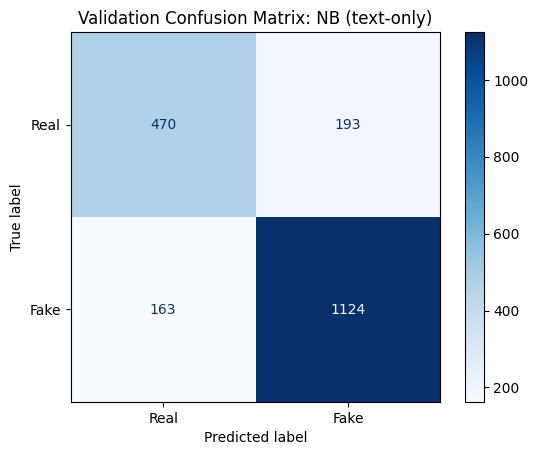

In [24]:
# Single baseline TF-IDF + MultinomialNB
# Small hyperparameter based search for alpha on validation set
alpha_grid = [0.1, 0.3, 0.5, 1.0]
val_rows = []

best_alpha = None
best_acc = -1
best_model = None
best_val_pred = None

for alpha in alpha_grid:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_text, y_train)
    pred = model.predict(X_val_text)
    m = evaluate_model(f"NB (alpha={alpha}) - val", y_val, pred)
    m["alpha"] = alpha
    val_rows.append(m)

    if m["accuracy"] > best_acc:
        best_acc = m["accuracy"]
        best_alpha = alpha
        best_model = model
        best_val_pred = pred

nb_model = best_model
val_pred_nb = best_val_pred

val_results = pd.DataFrame(val_rows).sort_values("accuracy", ascending=False)
print(f"Best alpha on validation: {best_alpha}")

print(f"Accuracy: {best_acc:.4f}")
print(classification_report(y_val, val_pred_nb, target_names=["Real", "Fake"], zero_division=0))

val_results

show_confusion(y_val, val_pred_nb, "Validation Confusion Matrix: NB (text-only)")

Task 1: Applying test set on simple model after training:

Final model: NB (best alpha=0.1)
Test Metrics:
Accuracy: 0.8224
              precision    recall  f1-score   support

        Real       0.75      0.74      0.74       685
        Fake       0.86      0.87      0.86      1269

    accuracy                           0.82      1954
   macro avg       0.81      0.80      0.80      1954
weighted avg       0.82      0.82      0.82      1954



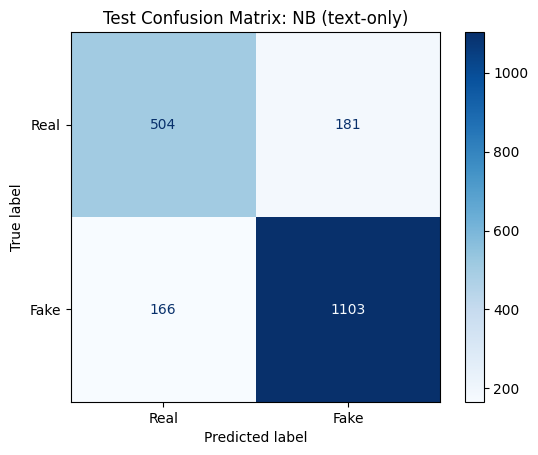

In [25]:
# test evaluation for the same baseline model
print(f"Final model: NB (best alpha={best_alpha})")

test_pred = nb_model.predict(X_test_text)
test_metrics = evaluate_model(f"NB (alpha={best_alpha}) - test", y_test, test_pred)

print("Test Metrics:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(classification_report(y_test, test_pred, target_names=["Real", "Fake"], zero_division=0))

pd.DataFrame([test_metrics])

show_confusion(y_test, test_pred, "Test Confusion Matrix: NB (text-only)")

Advanced TF-IDF + MLP

Initializing and training the model, then applying validation set:

Best MLP config on validation: {'hidden_layer_sizes': (50, 50), 'max_iter': 50}
Accuracy: 0.8379
              precision    recall  f1-score   support

        Real       0.79      0.71      0.75       663
        Fake       0.86      0.91      0.88      1287

    accuracy                           0.84      1950
   macro avg       0.83      0.81      0.81      1950
weighted avg       0.84      0.84      0.84      1950



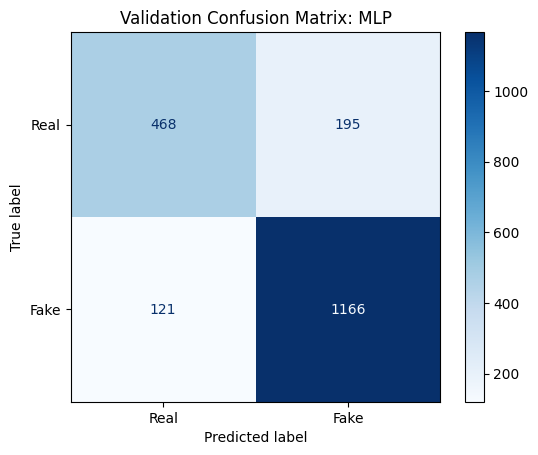

In [26]:
# MLP model (advanced predictor)
# Small hyperparameter based search for hidden layer sizes on validation set (baseline consistency, fair comparison)

mlp_configs = [{"hidden_layer_sizes": (100,), "max_iter": 50}, {"hidden_layer_sizes": (50, 50), "max_iter": 50}]
val_rows = []

best_config = None
best_acc = -1
best_model = None
best_val_pred = None

for config in mlp_configs:
    model = MLPClassifier(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        max_iter=config["max_iter"],
        random_state=42)
    model.fit(X_train_text, y_train)
    pred = model.predict(X_val_text)
    m = evaluate_model(f"MLP {config} - val", y_val, pred)
    m["config"] = str(config)
    val_rows.append(m)

    if m["accuracy"] > best_acc:
        best_acc = m["accuracy"]
        best_config = config
        best_model = model
        best_val_pred = pred
        
mlp_model = best_model
val_pred_mlp = best_val_pred

# Results (Same style as NB for consistency)
val_results = pd.DataFrame(val_rows).sort_values("accuracy", ascending=False)

print(f"Best MLP config on validation: {best_config}")

print(f"Accuracy: {best_acc:.4f}")
print(classification_report(y_val, val_pred_mlp, target_names=["Real", "Fake"], zero_division=0))

val_results

show_confusion(y_val, val_pred_mlp, "Validation Confusion Matrix: MLP")

Task 1: Applying test set on advanced model after training:

Final model: MLP
Test Metrics:
Accuracy: 0.8383
              precision    recall  f1-score   support

        Real       0.81      0.71      0.75       685
        Fake       0.85      0.91      0.88      1269

    accuracy                           0.84      1954
   macro avg       0.83      0.81      0.82      1954
weighted avg       0.84      0.84      0.84      1954



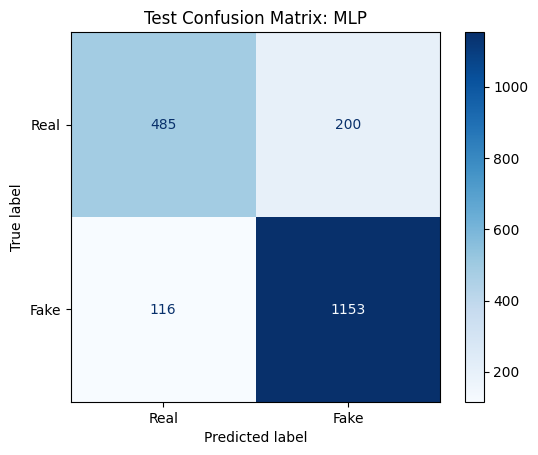

In [27]:
print(f"Final model: MLP")


test_pred = mlp_model.predict(X_test_text)
test_metrics = evaluate_model("MLP - test", y_test, test_pred)

print("Test Metrics:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(classification_report(y_test, test_pred, target_names=["Real", "Fake"], zero_division=0))

pd.DataFrame([test_metrics])

show_confusion(y_test, test_pred, "Test Confusion Matrix: MLP")

Task 2: Evaluating using the LIAR dataset

Loading the dataset test split, structuring and applying labels(0/1):

In [28]:
liar_df = pd.read_csv("../data/liar/test.tsv", sep="\t", header=None)

liar_df = liar_df[[1, 2]]
liar_df.columns = ["label", "content"]

real_labels = ["true", "mostly-true"]
fake_labels = ["false", "pants-fire", "barely-true", "half-true"]


def map_liar_label(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["label"] = out["label"].astype(str).str.lower().str.strip()

    keep = set(real_labels + fake_labels)
    out = out[out["label"].isin(keep)].copy()

    out["label"] = out["label"].apply(
        lambda x: 1 if x in fake_labels else 0
    ).astype(int)

    out["content"] = out["content"].fillna("").astype(str)
    out = out[out["content"].str.len() > 0]

    return out   

liar_df = map_liar_label(liar_df)


Confirming the dataset structure:

In [29]:
print(liar_df.head())
print("\nShape:", liar_df.shape)
print("\nLabel distribution:")
print(liar_df["label"].value_counts())

   label                                            content
0      0  Building a wall on the U.S.-Mexico border will...
1      1  Wisconsin is on pace to double the number of l...
2      1  Says John McCain has done nothing to help the ...
3      1  Suzanne Bonamici supports a plan that will cut...
4      1  When asked by a reporter whether hes at the ce...

Shape: (1267, 2)

Label distribution:
label
1    818
0    449
Name: count, dtype: int64


Fitting the dataset test split into simple & advanced model and printing the results (similarly to part 3 & 4):

LIAR test Metrics for NB:
Accuracy: 0.4183
              precision    recall  f1-score   support

        Real       0.32      0.58      0.42       449
        Fake       0.59      0.33      0.42       818

    accuracy                           0.42      1267
   macro avg       0.46      0.46      0.42      1267
weighted avg       0.49      0.42      0.42      1267

       model  accuracy  precision    recall        f1
0  NB - LIAR  0.418311   0.589011  0.327628  0.421053


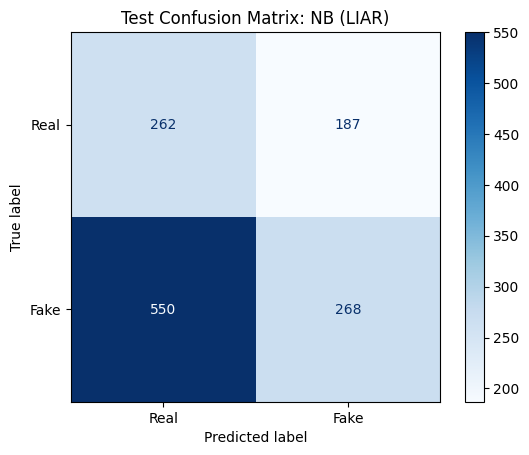

LIAR test Metrics for MLP:
Accuracy: 0.5572
              precision    recall  f1-score   support

        Real       0.33      0.25      0.29       449
        Fake       0.64      0.72      0.68       818

    accuracy                           0.56      1267
   macro avg       0.49      0.49      0.48      1267
weighted avg       0.53      0.56      0.54      1267

        model  accuracy  precision    recall        f1
0  MLP - LIAR  0.557222   0.638321  0.724939  0.678878


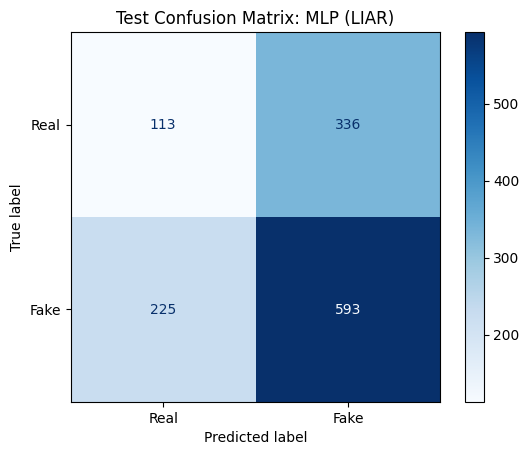

In [30]:
X_liar_clean = liar_df["content"].apply(preprocess_text)

X_liar_text = vectorizer.transform(X_liar_clean)

y_liar = liar_df["label"].values

liar_pred_nb = nb_model.predict(X_liar_text)
liar_pred_mlp = mlp_model.predict(X_liar_text)



test_metrics_nb = evaluate_model("NB - LIAR", y_liar, liar_pred_nb)
print("LIAR test Metrics for NB:")
print(f"Accuracy: {test_metrics_nb['accuracy']:.4f}")
print(classification_report(y_liar, liar_pred_nb, target_names=["Real", "Fake"], zero_division=0))

print(pd.DataFrame([test_metrics_nb]))

show_confusion(y_liar, liar_pred_nb, "Test Confusion Matrix: NB (LIAR)")




test_metrics_mlp = evaluate_model("MLP - LIAR", y_liar, liar_pred_mlp)

print("LIAR test Metrics for MLP:")
print(f"Accuracy: {test_metrics_mlp['accuracy']:.4f}")
print(classification_report(y_liar, liar_pred_mlp, target_names=["Real", "Fake"], zero_division=0))

print(pd.DataFrame([test_metrics_mlp]))
show_confusion(y_liar, liar_pred_mlp, "Test Confusion Matrix: MLP (LIAR)")